<a href="https://colab.research.google.com/github/astridcvr/daily-ml-practice/blob/main/day_04_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded: 2823 rows, 23 columns
Columns / Colonnes: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'CITY', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

✅ New columns added / Nouvelles colonnes ajoutées :
['TOTAL_ORDER_SALES', 'AVG_PRICE_ORDER', 'SALES_RATIO']

Data sample / Exemple de données :
   ORDERNUMBER    SALES  TOTAL_ORDER_SALES  AVG_PRICE_ORDER  SALES_RATIO
0        10107  2871.00           25783.76        92.801250     0.111349
1        10121  2765.90           18971.96        83.964000     0.145789
2        10134  3884.34           25624.88        90.441429     0.151585
3        10145  3746.70           55776.12        83.837500     0.067174
4        10159  5205.27           62498.29        83.056111     0.083287


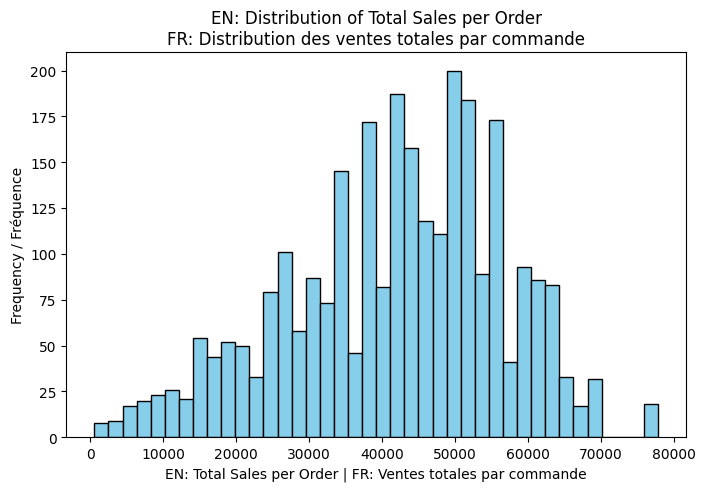

✅ File saved locally as 'sales_data_features.csv'


In [ ]:
# ===============================================================
# Day 04 – Feature Engineering / Ingénierie des variables
# ===============================================================

"""
🎯 Objective / Objectif :
EN: Create new features to enrich the dataset and extract more insights,
    including total sales per order, average price per order, and sales ratio.
FR: Créer de nouvelles variables pour enrichir le jeu de données et extraire
    plus d'informations, incluant les ventes totales par commande,
    le prix moyen par commande et le ratio des ventes.

📘 Description :
EN: This notebook focuses on adding derived metrics that summarize the
    performance of each order. These features will be used later for
    analysis and model training.
FR: Ce notebook se concentre sur l’ajout de métriques dérivées qui résument
    la performance de chaque commande. Ces variables seront utilisées plus
    tard pour l’analyse et l’entraînement du modèle.

📅 Author / Auteur : Astrid Villalobos
📍 Montréal, QC
"""

# === 1. Imports / Importations ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 2. Load cleaned dataset / Charger le jeu de données nettoyé ===
url = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/cleaned_sales_data.csv"
df = pd.read_csv(url, encoding="latin1")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns / Colonnes: {list(df.columns)}")

# === 3. Create new features / Créer de nouvelles variables ===
# 3.1 Total sales per order / Ventes totales par commande
total_sales_per_order = df.groupby("ORDERNUMBER")["SALES"].sum().reset_index()
total_sales_per_order.rename(columns={"SALES": "TOTAL_ORDER_SALES"}, inplace=True)
df = pd.merge(df, total_sales_per_order, on="ORDERNUMBER", how="left")

# 3.2 Average price per order / Prix moyen par commande
avg_price_per_order = df.groupby("ORDERNUMBER")["PRICEEACH"].mean().reset_index()
avg_price_per_order.rename(columns={"PRICEEACH": "AVG_PRICE_ORDER"}, inplace=True)
df = pd.merge(df, avg_price_per_order, on="ORDERNUMBER", how="left")

# 3.3 Sales ratio / Ratio des ventes
df["SALES_RATIO"] = df["SALES"] / df["TOTAL_ORDER_SALES"]

# === 4. Verify new features / Vérifier les nouvelles variables ===
print("\n✅ New columns added / Nouvelles colonnes ajoutées :")
print(["TOTAL_ORDER_SALES", "AVG_PRICE_ORDER", "SALES_RATIO"])

print("\nData sample / Exemple de données :")
print(df[["ORDERNUMBER", "SALES", "TOTAL_ORDER_SALES", "AVG_PRICE_ORDER", "SALES_RATIO"]].head())

# === 5. Visualize results / Visualiser les résultats ===
plt.figure(figsize=(8, 5))
plt.hist(df["TOTAL_ORDER_SALES"], bins=40, color="skyblue", edgecolor="black")
plt.title("EN: Distribution of Total Sales per Order\nFR: Distribution des ventes totales par commande")
plt.xlabel("EN: Total Sales per Order | FR: Ventes totales par commande")
plt.ylabel("Frequency / Fréquence")
plt.grid(False)
plt.show()

# === 6. Save engineered dataset / Sauvegarder le jeu de données ===
# Save locally in Colab
df.to_csv("sales_data_features.csv", index=False)
print("✅ File saved locally as 'sales_data_features.csv'")
